# **Grad-CAM Faithfulness Comparison — ECA vs SA vs CBAM vs CA**

Membandingkan 4 varian attention module (disisipkan di `patch_embed` ViT-Base/16) lewat dua hal:

1. **Faithfulness metrics** (Average Drop % & Increase in Confidence %) dihitung di seluruh test set.
2. **Visualisasi 1 foto** — heatmap Grad-CAM tiap varian ditampilkan berdampingan.

**Target layer Grad-CAM**: submodule attention di dalam `patch_embed` (output setelah `proj`, setelah attention diterapkan, sebelum di-flatten jadi token sequence). Ini satu-satunya titik yang masih berbentuk feature map 4D `(B, C, H, W)` di ViT — sekaligus persis titik di mana keempat varian secara struktural berbeda satu sama lain, jadi perbandingannya apple-to-apple. Untuk baseline (tanpa attention), target layer-nya adalah output `proj` langsung (titik yang setara).

# **Import Library**

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from tqdm import tqdm

import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# **Dataset Path & Config**

In [ ]:

TRAIN_DIR = "/kaggle/input/datasets/shubhamgoel27/dermnet/train"   
TEST_DIR  = "/kaggle/input/datasets/shubhamgoel27/dermnet/test"

classes      = sorted(os.listdir(TRAIN_DIR))
num_classes  = len(classes)

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_tf)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)


MAX_SAMPLES = None


# **Attention Module Definitions**


In [3]:
# ── ECA ────────────────────────────────────────────────────────────────────
class ECAAttention(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class ECAPatchEmbed(nn.Module):
    def __init__(self, original_patch_embed, eca_k_size=3):
        super().__init__()
        self.proj = original_patch_embed.proj
        self.norm = original_patch_embed.norm
        self.eca = ECAAttention(self.proj.out_channels, k_size=eca_k_size)

    def forward(self, x):
        x = self.proj(x)
        x = self.eca(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x


# ── SA (Spatial Attention, CBAM-style, dipakai sendirian) ───────────────────
class SA_SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class SAPatchEmbed(nn.Module):
    def __init__(self, original_patch_embed, sa_kernel_size=7):
        super().__init__()
        self.proj = original_patch_embed.proj
        self.norm = original_patch_embed.norm
        self.sa = SA_SpatialAttention(kernel_size=sa_kernel_size)

    def forward(self, x):
        x = self.proj(x)
        x = self.sa(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x


# ── CBAM (Channel lalu Spatial, berurutan) ───────────────────────────────────
class CBAM_ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class CBAM_SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(x))


class CBAMAttention(nn.Module):
    def __init__(self, channels, ratio=16, spatial_k=7):
        super().__init__()
        self.ca = CBAM_ChannelAttention(channels, ratio=ratio)
        self.sa = CBAM_SpatialAttention(kernel_size=spatial_k)

    def forward(self, x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x


class CBAMPatchEmbed(nn.Module):
    def __init__(self, original_patch_embed, cbam_ratio=16, cbam_spatial_k=7):
        super().__init__()
        self.proj = original_patch_embed.proj
        self.norm = original_patch_embed.norm
        self.cbam = CBAMAttention(self.proj.out_channels, ratio=cbam_ratio, spatial_k=cbam_spatial_k)

    def forward(self, x):
        x = self.proj(x)
        x = self.cbam(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x


# # ── CA (Coordinate Attention) ────────────────────────────────────────────────
# class CoordAtt(nn.Module):
#     def __init__(self, channels, reduction=32):
#         super().__init__()
#         self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
#         self.pool_w = nn.AdaptiveAvgPool2d((1, None))

#         mip = max(8, channels // reduction)

#         self.conv1 = nn.Conv2d(channels, mip, kernel_size=1, stride=1, padding=0)
#         self.bn1   = nn.BatchNorm2d(mip)
#         self.act   = nn.Hardswish()

#         self.conv_h = nn.Conv2d(mip, channels, kernel_size=1, stride=1, padding=0)
#         self.conv_w = nn.Conv2d(mip, channels, kernel_size=1, stride=1, padding=0)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         identity = x
#         n, c, h, w = x.size()

#         x_h = self.pool_h(x)
#         x_w = self.pool_w(x).permute(0, 1, 3, 2)

#         y = torch.cat([x_h, x_w], dim=2)
#         y = self.conv1(y)
#         y = self.bn1(y)
#         y = self.act(y)

#         x_h, x_w = torch.split(y, [h, w], dim=2)
#         x_w = x_w.permute(0, 1, 3, 2)
#         a_h = self.sigmoid(self.conv_h(x_h))
#         a_w = self.sigmoid(self.conv_w(x_w))

#         out = identity * a_h * a_w
#         return out


# class CoordAttPatchEmbed(nn.Module):
#     def __init__(self, original_patch_embed, coordatt_reduction=32):
#         super().__init__()
#         self.proj = original_patch_embed.proj
#         self.norm = original_patch_embed.norm
#         self.coordatt = CoordAtt(self.proj.out_channels, reduction=coordatt_reduction)

#     def forward(self, x):
#         x = self.proj(x)
#         x = self.coordatt(x)
#         x = x.flatten(2).transpose(1, 2)
#         x = self.norm(x)
#         return x


# **Konfigurasi Varian & Model Loader**

In [ ]:
VARIANT_CONFIGS = {
    "Baseline": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/test-gradcam-1/other/1/1/model_fold_4.pth",
        "wrap_fn": None,
        "attr": None,   
    },
    "ECA": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/test-gradcam-1/other/1/1/model_fold_5.pth", 
        "wrap_fn": lambda pe: ECAPatchEmbed(pe, eca_k_size=3),
        "attr": "eca",
    },
    "SA": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/test-gradcam-1/other/1/1/model_fold_5 (1).pth", 
        "wrap_fn": lambda pe: SAPatchEmbed(pe, sa_kernel_size=7),
        "attr": "sa",
    },
    "CBAM": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/test-gradcam-1/other/1/1/model_fold_2.pth",  
        "wrap_fn": lambda pe: CBAMPatchEmbed(pe, cbam_ratio=16, cbam_spatial_k=7),
        "attr": "cbam",
    },
    # "CA": {
    #     "checkpoint": "/kaggle/input/.../exp04_best.pth",   # TODO: isi path checkpoint EXP04
    #     "wrap_fn": lambda pe: CoordAttPatchEmbed(pe, coordatt_reduction=32),
    #     "attr": "coordatt",
    # },
}


def load_model(variant_name, num_classes, device):
    """Bangun ulang arsitektur ViT-Base/16 + wrap patch_embed sesuai varian,
    lalu load checkpoint. Urutan wrap SEBELUM load_state_dict wajib -- sama
    seperti di cell Test Evaluation pada notebook training masing-masing EXP."""
    cfg = VARIANT_CONFIGS[variant_name]

    model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)
    if cfg["wrap_fn"] is not None:
        model.patch_embed = cfg["wrap_fn"](model.patch_embed)
    model = model.to(device)

    checkpoint = torch.load(cfg["checkpoint"], map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def get_target_layer(model, variant_name):
    """Titik hook Grad-CAM: submodule attention di patch_embed (post-proj,
    post-attention, pre-flatten -- masih 4D). Untuk Baseline (tanpa attention),
    titik yang setara adalah output proj itu sendiri."""
    attr = VARIANT_CONFIGS[variant_name]["attr"]
    if attr is None:
        return model.patch_embed.proj
    return getattr(model.patch_embed, attr)


def get_target_layer_decision(model):
    """Titik hook Grad-CAM level KEPUTUSAN AKHIR: LayerNorm pertama di blok
    transformer terakhir (model.blocks[-1].norm1) -- konvensi umum untuk
    Grad-CAM pada ViT (dipakai juga di library pytorch-grad-cam). Titik ini
    sama untuk kelima varian (Baseline/ECA/SA/CBAM/CA), karena attention
    module cuma disisipkan di patch_embed, bukan di dalam blok transformer.
    Outputnya berbentuk token sequence (B, N, C), N = 1 CLS token + 196 patch
    token -> butuh reshape_transform sebelum bisa dipakai seperti CAM biasa."""
    return model.blocks[-1].norm1


# **Grad-CAM Implementation**

In [5]:
class GradCAM:
    def __init__(self, model, target_layer, reshape_transform=None):
        """
        reshape_transform: opsional. Kalau target_layer outputnya berbentuk token
        sequence (B, N, C) -- kayak di dalam blok transformer ViT -- kasih fungsi
        ini untuk mengubahnya balik ke feature map spasial (B, C, H, W) sebelum
        Grad-CAM dihitung. Untuk hook di patch_embed (masih 4D), biarkan None.
        """
        self.model = model
        self.target_layer = target_layer
        self.reshape_transform = reshape_transform
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self._bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor : (B, 3, H, W), sudah dinormalisasi (eval_tf)
        class_idx    : (B,) target kelas. Default = prediksi model sendiri
                       (standar untuk faithfulness eval -- bukan ground truth).
        Return: cam (B, H, W) dalam rentang [0, 1], probs (B, num_classes), class_idx (B,)
        """
        self.model.zero_grad(set_to_none=True)
        # requires_grad_ di input -> hilangkan warning "no inputs require gradients"
        # dari register_full_backward_hook (kita hanya butuh grad_output, tapi PyTorch
        # tetap warn kalau grad tidak mengalir ke input module).
        input_tensor = input_tensor.clone().requires_grad_(True)
        output = self.model(input_tensor)                 # (B, num_classes)
        probs  = output.softmax(dim=1)

        if class_idx is None:
            class_idx = output.argmax(dim=1)

        selected = output[torch.arange(output.size(0), device=output.device), class_idx]
        selected.sum().backward()

        activations = self.activations
        gradients   = self.gradients
        if self.reshape_transform is not None:
            # token sequence (B, N, C) -> feature map spasial (B, C, H, W)
            activations = self.reshape_transform(activations)
            gradients   = self.reshape_transform(gradients)

        weights = gradients.mean(dim=(2, 3), keepdim=True)      # GAP gradien per channel
        cam = (weights * activations).sum(dim=1, keepdim=True)  # (B, 1, h, w)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam_flat = cam.view(cam.size(0), -1)
        cam_min  = cam_flat.min(dim=1)[0].view(-1, 1, 1, 1)
        cam_max  = cam_flat.max(dim=1)[0].view(-1, 1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.squeeze(1).detach(), probs.detach(), class_idx.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()


# **Faithfulness Metrics — Average Drop % & Increase in Confidence %**
- **Average Drop %** = rata-rata `max(0, Y_c - O_c) / Y_c`, dikali 100. `Y_c` = confidence model pada kelas prediksi memakai gambar asli; `O_c` = confidence pada gambar yang sudah di-mask pakai CAM (elementwise `image * cam`). Semakin RENDAH semakin baik (region yang disorot CAM benar-benar penting buat keputusan model).
- **Increase in Confidence %** = persentase sample di mana `O_c > Y_c` (masking dengan CAM malah menaikkan confidence). Semakin TINGGI semakin baik.

In [6]:
def compute_faithfulness(model, gradcam, dataloader, device, max_samples=None):
    total_drop     = 0.0
    increase_count = 0
    n_samples      = 0

    for images, _ in tqdm(dataloader, desc="Faithfulness eval"):
        images = images.to(device)

        cams, probs, pred_idx = gradcam.generate(images)
        Y = probs[torch.arange(probs.size(0), device=device), pred_idx]

        masked_images = images * cams.unsqueeze(1)   # mask diterapkan di tensor ternormalisasi
        with torch.no_grad():
            masked_output = model(masked_images)
            masked_probs  = masked_output.softmax(dim=1)
        O = masked_probs[torch.arange(masked_probs.size(0), device=device), pred_idx]

        drop = torch.clamp(Y - O, min=0) / (Y + 1e-8)
        total_drop     += drop.sum().item()
        increase_count += (O > Y).sum().item()
        n_samples      += images.size(0)

        if max_samples is not None and n_samples >= max_samples:
            break

    avg_drop_pct = (total_drop / n_samples) * 100
    iic_pct      = (increase_count / n_samples) * 100
    return avg_drop_pct, iic_pct, n_samples


# **Level 1 — Jalankan Perbandingan (Titik Hook: Patch Embedding / Awal)**

In [7]:
results_level1 = []

for variant_name in VARIANT_CONFIGS.keys():
    print(f"\n{'='*50}\n  {variant_name}\n{'='*50}")

    model = load_model(variant_name, num_classes, device)
    target_layer = get_target_layer(model, variant_name)
    gradcam = GradCAM(model, target_layer)

    avg_drop, iic, n = compute_faithfulness(model, gradcam, test_loader, device, max_samples=MAX_SAMPLES)
    print(f"  Average Drop %        : {avg_drop:.2f}")
    print(f"  Increase in Confidence%: {iic:.2f}")
    print(f"  N samples evaluated    : {n}")

    results_level1.append({
        "Variant": variant_name,
        "Average_Drop_%": avg_drop,
        "Increase_in_Confidence_%": iic,
        "N_samples": n,
    })

    gradcam.remove_hooks()
    del model, gradcam
    torch.cuda.empty_cache()

results_df_level1 = pd.DataFrame(results_level1)
print("\n", results_df_level1)

os.makedirs("outputs", exist_ok=True)
results_df_level1.to_csv("outputs/GradCAM_Faithfulness_Comparison_Level1_PatchEmbed.csv", index=False)
print("\n✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level1_PatchEmbed.csv")



  Baseline


Faithfulness eval: 100%|██████████| 251/251 [03:51<00:00,  1.08it/s]


  Average Drop %        : 71.10
  Increase in Confidence%: 5.52
  N samples evaluated    : 4002

  ECA


Faithfulness eval: 100%|██████████| 251/251 [03:32<00:00,  1.18it/s]


  Average Drop %        : 77.75
  Increase in Confidence%: 5.00
  N samples evaluated    : 4002

  SA


Faithfulness eval: 100%|██████████| 251/251 [03:33<00:00,  1.18it/s]


  Average Drop %        : 70.10
  Increase in Confidence%: 7.55
  N samples evaluated    : 4002

  CBAM


Faithfulness eval: 100%|██████████| 251/251 [03:39<00:00,  1.14it/s]


  Average Drop %        : 80.22
  Increase in Confidence%: 3.87
  N samples evaluated    : 4002

     Variant  Average_Drop_%  Increase_in_Confidence_%  N_samples
0  Baseline       71.097649                  5.522239       4002
1       ECA       77.748410                  4.997501       4002
2        SA       70.099834                  7.546227       4002
3      CBAM       80.220284                  3.873063       4002

✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level1_PatchEmbed.csv


# **Level 1 — Grafik Perbandingan (Patch Embedding)**

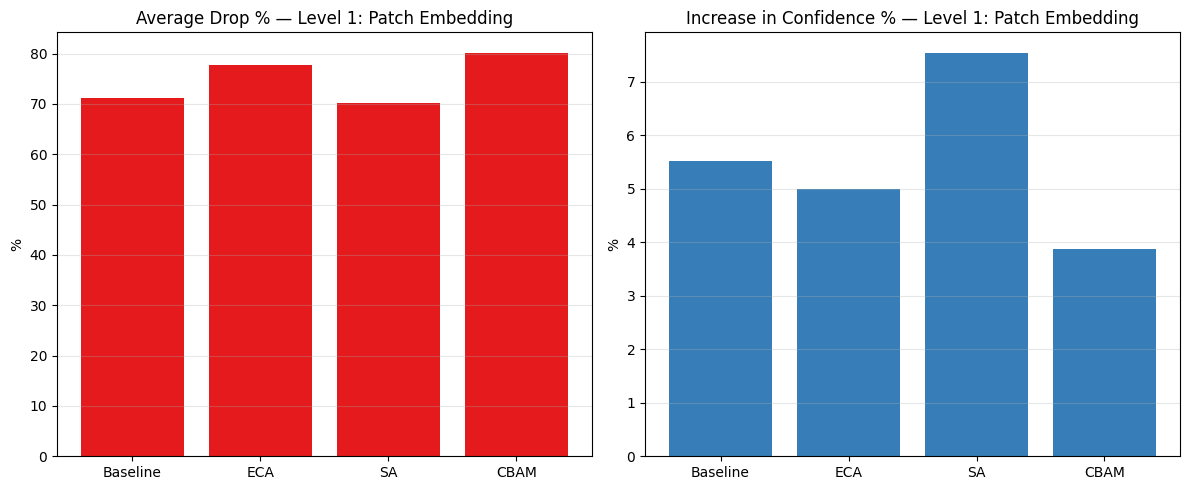

✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level1.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df_level1["Variant"], results_df_level1["Average_Drop_%"], color="#e41a1c")
axes[0].set_title("Average Drop % — Level 1: Patch Embedding")
axes[0].set_ylabel("%")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(results_df_level1["Variant"], results_df_level1["Increase_in_Confidence_%"], color="#377eb8")
axes[1].set_title("Increase in Confidence % — Level 1: Patch Embedding")
axes[1].set_ylabel("%")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/GradCAM_Faithfulness_BarChart_Level1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level1.png")


# **Visualisasi 1 Foto — Bandingkan Heatmap Semua Varian**

✓ Disimpan -> outputs/GradCAM_SingleImage_Comparison.png


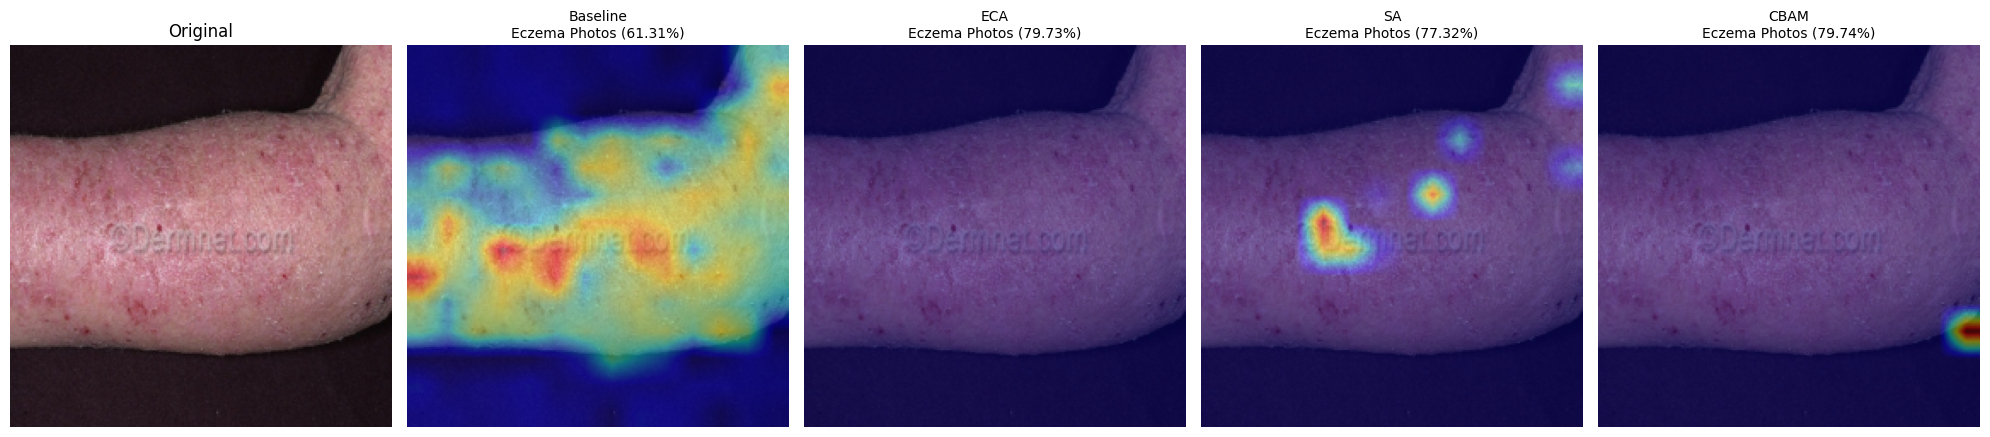

In [ ]:
def unnormalize(tensor):
    """(1,3,H,W) ternormalisasi -> (H,W,3) uint8 pixel space, untuk overlay & display."""
    img = tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).squeeze(0).permute(1, 2, 0).numpy()
    return img


def overlay_cam(image_rgb, cam, alpha=0.45):
    """image_rgb: (H,W,3) float [0,1]; cam: (H,W) float [0,1] -> overlay heatmap Jet."""
    heatmap = matplotlib.cm.jet(cam)[:, :, :3]   
    overlay = (1 - alpha) * image_rgb + alpha * heatmap
    return np.clip(overlay, 0, 1)


def compare_single_image(image_path, num_classes, device, save_path=None):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_tf(image).unsqueeze(0).to(device)

    variant_names = list(VARIANT_CONFIGS.keys())
    fig, axes = plt.subplots(1, len(variant_names) + 1, figsize=(4 * (len(variant_names) + 1), 4.5))

    # Panel pertama: gambar asli
    original_rgb = unnormalize(input_tensor)
    axes[0].imshow(original_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for ax, variant_name in zip(axes[1:], variant_names):
        model = load_model(variant_name, num_classes, device)
        target_layer = get_target_layer(model, variant_name)
        gradcam = GradCAM(model, target_layer)

        cams, probs, pred_idx = gradcam.generate(input_tensor)
        cam_np   = cams.squeeze(0).cpu().numpy()
        conf     = probs[0, pred_idx[0]].item()
        pred_cls = classes[pred_idx[0].item()]

        overlay = overlay_cam(original_rgb, cam_np)
        ax.imshow(overlay)
        ax.set_title(f"{variant_name}\n{pred_cls} ({conf:.2%})", fontsize=10)
        ax.axis("off")

        gradcam.remove_hooks()
        del model, gradcam
        torch.cuda.empty_cache()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Disimpan -> {save_path}")
    plt.show()



SAMPLE_IMAGE_PATH = "/kaggle/input/datasets/devianestnarendra/picturetest-gradcam/03DermatitisArm1.jpg" 
compare_single_image(
    SAMPLE_IMAGE_PATH,
    num_classes,
    device,
    save_path="outputs/GradCAM_SingleImage_Comparison.png"
)


# **Level 2 — Faithfulness di Level Keputusan Akhir (Blok Transformer Terakhir)**

Bagian ini menjawab pertanyaan yang beda dari Level 1: bukan "attention module fokus ke mana di awal", tapi **"bagian gambar mana yang benar-benar dipakai model untuk keputusan akhirnya"**.

Titik hook-nya di `model.blocks[-1].norm1` — masuk ke blok transformer terakhir. Output di sini berbentuk **token sequence** `(B, N, C)`, bukan feature map `(B, C, H, W)` seperti di patch_embed, karena representasinya sudah melewati 11 blok transformer sebelumnya. Ada 197 token: 1 token CLS (ringkasan global, tidak punya posisi di gambar) + 196 token patch (grid 14×14, sesuai 224/16 = 14 patch per sisi).

`reshape_transform` di bawah membuang token CLS, lalu menyusun 196 token sisanya balik jadi grid spasial 14×14 supaya bisa diproses Grad-CAM seperti biasa.

In [10]:
PATCH_GRID = 224 // 16   # = 14, ukuran grid patch ViT-Base/16 untuk input 224x224

def vit_reshape_transform(tensor, grid_size=PATCH_GRID):
    """
    tensor: (B, N, C) dari blok transformer, N = 1 (CLS) + grid_size*grid_size (patch token)
    return: (B, C, grid_size, grid_size) -- feature map spasial, siap dipakai GradCAM
    """
    # buang token CLS (index 0), sisakan 196 token patch
    result = tensor[:, 1:, :]
    B, N, C = result.shape
    assert N == grid_size * grid_size, f"Jumlah token ({N}) tidak cocok dengan grid {grid_size}x{grid_size}"
    result = result.reshape(B, grid_size, grid_size, C)
    result = result.permute(0, 3, 1, 2)   # (B, C, H, W)
    return result


# **Level 2 — Jalankan Perbandingan (Titik Hook: Blok Transformer Terakhir)**

In [11]:
results_level2 = []

for variant_name in VARIANT_CONFIGS.keys():
    print(f"\n{'='*50}\n  {variant_name} (Level 2 -- decision layer)\n{'='*50}")

    model = load_model(variant_name, num_classes, device)
    target_layer = get_target_layer_decision(model)
    gradcam = GradCAM(model, target_layer, reshape_transform=vit_reshape_transform)

    avg_drop, iic, n = compute_faithfulness(model, gradcam, test_loader, device, max_samples=MAX_SAMPLES)
    print(f"  Average Drop %        : {avg_drop:.2f}")
    print(f"  Increase in Confidence%: {iic:.2f}")
    print(f"  N samples evaluated    : {n}")

    results_level2.append({
        "Variant": variant_name,
        "Average_Drop_%": avg_drop,
        "Increase_in_Confidence_%": iic,
        "N_samples": n,
    })

    gradcam.remove_hooks()
    del model, gradcam
    torch.cuda.empty_cache()

results_df_level2 = pd.DataFrame(results_level2)
print("\n", results_df_level2)

os.makedirs("outputs", exist_ok=True)
results_df_level2.to_csv("outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv", index=False)
print("\n✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv")



  Baseline (Level 2 -- decision layer)


Faithfulness eval: 100%|██████████| 251/251 [03:34<00:00,  1.17it/s]


  Average Drop %        : 67.04
  Increase in Confidence%: 6.07
  N samples evaluated    : 4002

  ECA (Level 2 -- decision layer)


Faithfulness eval: 100%|██████████| 251/251 [03:35<00:00,  1.17it/s]


  Average Drop %        : 70.16
  Increase in Confidence%: 7.42
  N samples evaluated    : 4002

  SA (Level 2 -- decision layer)


Faithfulness eval: 100%|██████████| 251/251 [03:35<00:00,  1.17it/s]


  Average Drop %        : 64.63
  Increase in Confidence%: 8.75
  N samples evaluated    : 4002

  CBAM (Level 2 -- decision layer)


Faithfulness eval: 100%|██████████| 251/251 [03:36<00:00,  1.16it/s]


  Average Drop %        : 72.53
  Increase in Confidence%: 6.67
  N samples evaluated    : 4002

     Variant  Average_Drop_%  Increase_in_Confidence_%  N_samples
0  Baseline       67.038715                  6.071964       4002
1       ECA       70.158484                  7.421289       4002
2        SA       64.634276                  8.745627       4002
3      CBAM       72.530930                  6.671664       4002

✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv


# **Level 2 — Grafik Perbandingan (Blok Transformer Terakhir)**

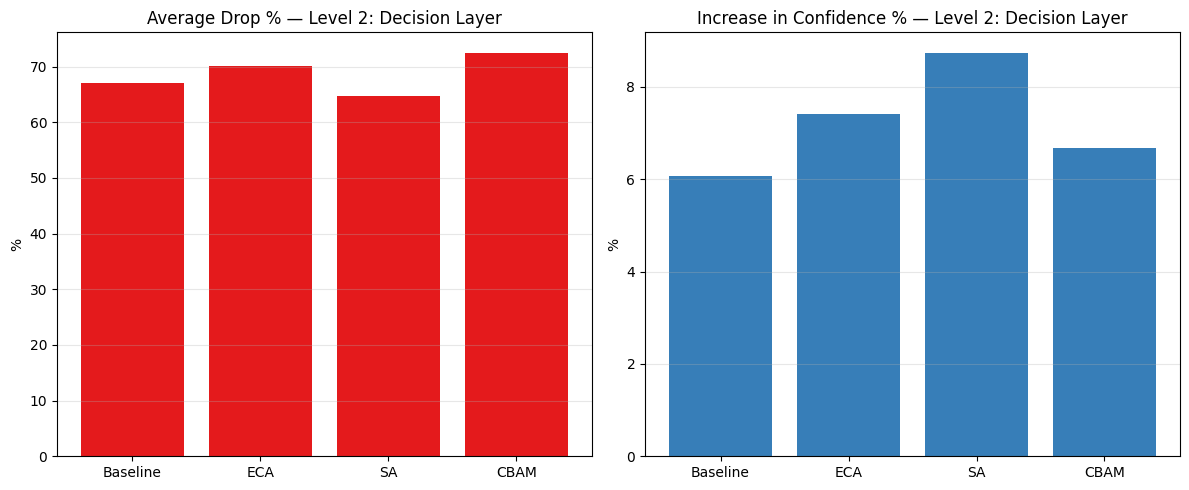

✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level2.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df_level2["Variant"], results_df_level2["Average_Drop_%"], color="#e41a1c")
axes[0].set_title("Average Drop % — Level 2: Decision Layer")
axes[0].set_ylabel("%")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(results_df_level2["Variant"], results_df_level2["Increase_in_Confidence_%"], color="#377eb8")
axes[1].set_title("Increase in Confidence % — Level 2: Decision Layer")
axes[1].set_ylabel("%")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/GradCAM_Faithfulness_BarChart_Level2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level2.png")


# **Level 1 vs Level 2 — Ringkasan Berdampingan**

In [13]:
comparison = results_df_level1.merge(
    results_df_level2, on="Variant", suffixes=("_Level1_PatchEmbed", "_Level2_DecisionLayer")
)
comparison = comparison[[
    "Variant",
    "Average_Drop_%_Level1_PatchEmbed", "Average_Drop_%_Level2_DecisionLayer",
    "Increase_in_Confidence_%_Level1_PatchEmbed", "Increase_in_Confidence_%_Level2_DecisionLayer",
]]
comparison.to_csv("outputs/GradCAM_Faithfulness_Level1_vs_Level2.csv", index=False)
comparison


,Variant,Average_Drop_%_Level1_PatchEmbed,Average_Drop_%_Level2_DecisionLayer,Increase_in_Confidence_%_Level1_PatchEmbed,Increase_in_Confidence_%_Level2_DecisionLayer
0,Baseline,71.097649,67.038715,5.522239,6.071964
1,ECA,77.748410,70.158484,4.997501,7.421289
2,SA,70.099834,64.634276,7.546227,8.745627
3,CBAM,80.220284,72.530930,3.873063,6.671664


# **Visualisasi 1 Foto — Level 1 vs Level 2, Semua Varian**

✓ Disimpan -> outputs/GradCAM_SingleImage_Level1_vs_Level2.png


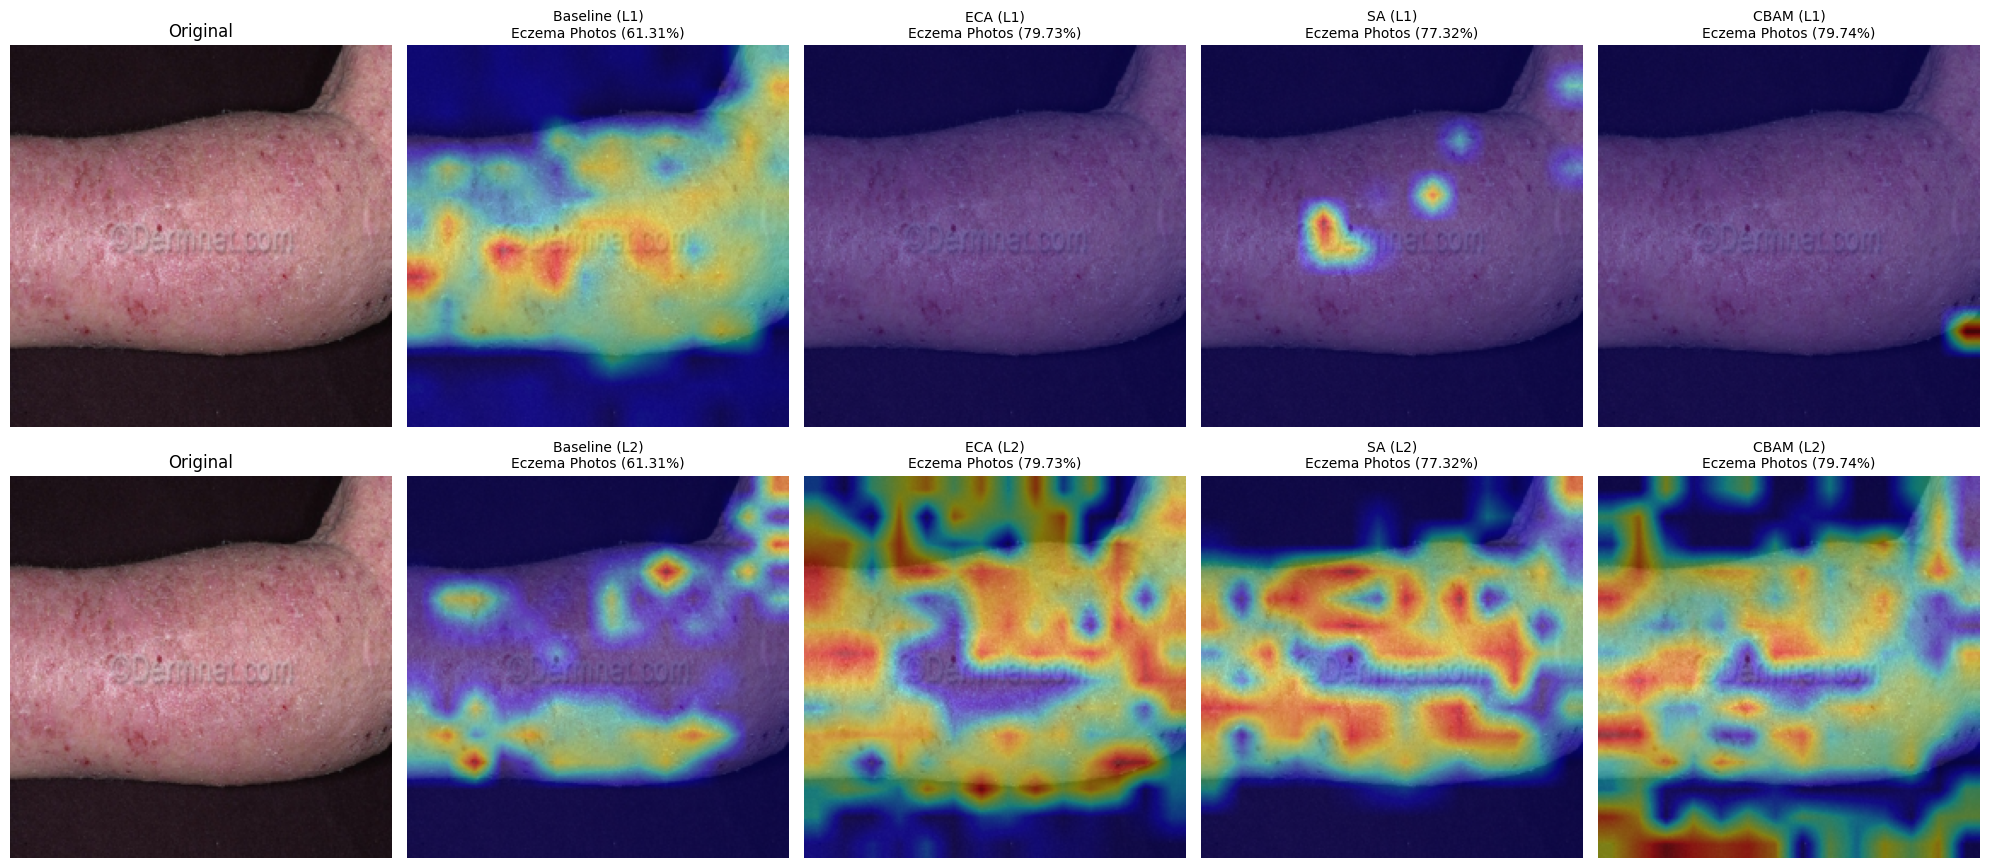

In [14]:
def compare_single_image_both_levels(image_path, num_classes, device, save_path=None):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_tf(image).unsqueeze(0).to(device)
    original_rgb = unnormalize(input_tensor)

    variant_names = list(VARIANT_CONFIGS.keys())
    n_cols = len(variant_names) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 9))

    axes[0, 0].imshow(original_rgb)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    axes[1, 0].imshow(original_rgb)
    axes[1, 0].set_title("Original")
    axes[1, 0].axis("off")

    for col, variant_name in enumerate(variant_names, start=1):
        model = load_model(variant_name, num_classes, device)

        # ── Level 1: patch embedding ──
        target_l1 = get_target_layer(model, variant_name)
        gradcam_l1 = GradCAM(model, target_l1)
        cam_l1, probs_l1, pred_l1 = gradcam_l1.generate(input_tensor)
        overlay_l1 = overlay_cam(original_rgb, cam_l1.squeeze(0).cpu().numpy())
        axes[0, col].imshow(overlay_l1)
        axes[0, col].set_title(
            f"{variant_name} (L1)\n{classes[pred_l1[0].item()]} ({probs_l1[0, pred_l1[0]].item():.2%})",
            fontsize=10
        )
        axes[0, col].axis("off")
        gradcam_l1.remove_hooks()

        # ── Level 2: decision layer ──
        target_l2 = get_target_layer_decision(model)
        gradcam_l2 = GradCAM(model, target_l2, reshape_transform=vit_reshape_transform)
        cam_l2, probs_l2, pred_l2 = gradcam_l2.generate(input_tensor)
        overlay_l2 = overlay_cam(original_rgb, cam_l2.squeeze(0).cpu().numpy())
        axes[1, col].imshow(overlay_l2)
        axes[1, col].set_title(
            f"{variant_name} (L2)\n{classes[pred_l2[0].item()]} ({probs_l2[0, pred_l2[0]].item():.2%})",
            fontsize=10
        )
        axes[1, col].axis("off")
        gradcam_l2.remove_hooks()

        del model, gradcam_l1, gradcam_l2
        torch.cuda.empty_cache()

    axes[0, 0].set_ylabel("Level 1\n(Patch Embedding)", fontsize=11)
    axes[1, 0].set_ylabel("Level 2\n(Decision Layer)", fontsize=11)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Disimpan -> {save_path}")
    plt.show()


compare_single_image_both_levels(
    SAMPLE_IMAGE_PATH,
    num_classes,
    device,
    save_path="outputs/GradCAM_SingleImage_Level1_vs_Level2.png"
)
